In [162]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
import random
import json, IPython, re
import requests

In [163]:
class AgentState(TypedDict):
    text : str
    outtext : str
    sh : dict
    fh : str
    diagnosis : str
    medication : str
    vitals : str
    diagnostics : str
    labs : str
    icdcptsnomed : str

In [164]:
# import random

# def social_history(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["sh"]="Social history is present in the page and will be handled by kavin and gangesh"
#     else:
#         state["sh"]="Social history is not present in the page"     
    
#     return state          #same input text is being passed on to all the nodes "text","outtext" and overwritten finally so there is an issue
# #so we use the below code instead

# def family_history(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["fh"]="Family history is present in the page and will be handled by jeba"
#     else:
#         state["fh"]="Family history is not present in the page"
    
#     return state

# def diagnosis(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["diagnosis"]="Diagnosis is present in the page and will be handled by jeba"
#     else:
#         state["diagnosis"]="Diagnosis is not present in the page"
    
#     return state

# def medication(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["medication"]="Medication is present in the page and will be handled by roshini"
#     else:
#         state["medication"]="Medication is not present in the page"
    
#     return state

# def vitals(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["vitals"]="Vitals is present in the page and will be handled by Sivaranjini"
#     else:
#         state["vitals"]="Vitals is not present in the page"
    
#     return state

# def diagnostics(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["diagnostics"]="Vitals is present in the page and will be handled by Sivaranjini"
#     else:
#         state["diagnostics"]="Vitals is not present in the page"
    
#     return state

# def labs(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["labs"]="Labs is present in the page and will be handled by Dhana anna"
#     else:
#         state["labs"]="Labs is not present in the page"
    
#     return state

# def icdcptsnomed(state:AgentState) -> AgentState :
#     result = random.choice(["Present", "Not Present"])
    
#     if result == "Present":
#         state["icdcptsnomed"]="ICD, CPT and Snomed codes is present in the page and will be handled by Gangesh and Roshini"
#     else:
#         state["icdcptsnomed"]="ICD, CPT and Snomed codes is not present in the page"
    
#     return state




In [165]:
def vertexAI_endpint(context, context_length, SYSTEM_PROMPT):

    try:
        url = "http://172.16.36.10:9006/generate" 

        payload = json.dumps({
        "context": context,
        "context_length": context_length,
        "SYSTEM_PROMPT": SYSTEM_PROMPT
        })
        
        headers = {
        'Content-Type': 'application/json'
        }

        response = requests.request("POST", url, headers=headers, data=payload,timeout=120)
        #print(json.loads(response.text)['result'])
        return json.loads(response.text)['result']

    except Exception as e:
        print(e)

In [166]:
def social_history(state:AgentState):
    try:
        Classification_instructions = """
        You are a medical document classification engine.

        TASK:
        Determine whether the provided text contains valid Social History information.

        Return ONLY one JSON object:
        {"report_type": "social history"}
        OR
        {"report_type": "No"}

        ------------------------------------------------------------
        DEFINITION

        Social History refers to structured documentation of patient
        lifestyle, behavioral, or social determinant information.

        This includes:

        - Tobacco / Smoking / Vaping / Nicotine use
        - Alcohol use / ETOH
        - Illicit or recreational drug use
        - Exercise habits
        - Occupation / Employment
        - Homelessness
        - Disability
        - Military service
        - Avocation / hobbies
        - Financial or social hardship

        ------------------------------------------------------------
        CLASSIFY AS "social history" IF:

        1) The content appears under a clearly labeled section such as:
        - Social History
        - SH:
        - Substance Use
        - Lifestyle
        - Personal History
        - Occupation
        - Social Determinants

        OR

        2) The text contains TWO OR MORE structured
        question-answer entries about:
        - Tobacco use
        - Alcohol use
        - Illicit or recreational drug use

        Example structure:
        "Do you smoke?: No"
        "Alcohol use?: Occasional"
        "Do you use illicit drugs?: None"

        Structured Q&A format qualifies even if
        a Social History header is not visible.

        ------------------------------------------------------------
        MUST CLASSIFY AS "No" IF:

        - Lifestyle details appear casually inside:
        HPI, Assessment, Plan, Physical Exam,
        Progress Notes, or narrative paragraphs.

        - Information refers to family members instead of the patient.

        - Content primarily discusses:
        Medications, Labs, Imaging,
        Diagnoses, Vitals, Surgical history.

        ------------------------------------------------------------
        OCR ROBUSTNESS

        Minor OCR spelling errors are acceptable if
        structure is clear (e.g., "Alcohal", "ET0H", "Substnce").

        If structure is unclear ? classify as "No".

        ------------------------------------------------------------
        NO INFERENCE RULE

        Do NOT infer Social History.
        Explicit structured documentation is required.

        If uncertain ? return {"report_type": "No"}.

        ------------------------------------------------------------
        OUTPUT FORMAT (STRICT)

        Return ONLY:

        {"report_type": "social history"}

        OR

        {"report_type": "No"}

        No additional text.
        """

        raw_output = vertexAI_endpint(state["text"], 1024, Classification_instructions)

        # ---------------------------
        # Clean markdown wrapping
        # ---------------------------
        if raw_output.startswith("```"):
            raw_output = raw_output.strip("`")
            raw_output = raw_output.replace("json", "", 1).strip()

        # ---------------------------
        # Safe JSON parsing
        # ---------------------------
        try:
            parsed = json.loads(raw_output)

            return {'sh' : parsed}

        except json.JSONDecodeError:
            # Remove trailing commas
            cleaned = re.sub(r",\s*([\]}])", r"\1", raw_output)

            try:
                parsed = json.loads(cleaned)

                return {'sh': parsed}

            except Exception as e:
                return {'sh': "error appeared1 "}

    except Exception as e:
        return {'sh': "error appeared2 "}



In [167]:
def vitals(state: AgentState):
    vital_clasify_prompt = """You are an AI assistant specializing in text classification. Your task is to determine if the given content contains vital signs data.  
 
                            **Instructions:**  
                            - Read the entire content carefully.  
                            - If the content includes vital signs (e.g., heart rate, blood pressure, temperature, respiratory rate, oxygen saturation, weight, height,bmi-, etc.), classify it as `"vitals"`.  
                            - If no vital signs data are present, classify it as `"not_vitals"`.  
 
                            **Output Format (JSON):**  
                            {
                            "type": "vitals"  // or "not_vitals"
                            }
 
                        """
   
    try:
        if state["text"].strip():
            llm_output = vertexAI_endpint(state["text"], 1024, vital_clasify_prompt)
            if llm_output:
                # Clean up the output in case the model adds backticks
                cleaned_output = llm_output.strip()
                cleaned_output = cleaned_output.replace("```json", "").replace("```", "").strip()

                classify_output = json.loads(cleaned_output)
                if "result" in classify_output:
                    inner_json = json.loads(classify_output["result"])
                    return {"vitals": inner_json}
                else:
                    inner_json = classify_output
                    return {"vitals": inner_json}
              
    except Exception as e: 
        return {"vitals":"error appeared"}

In [175]:
def diagnostics(state:AgentState):
    diagnostics_clasify_prompt = """You are an expert medical document analys. Your task is to determine if the given content contains diagnostics data.  
 
                                    Instructions:
                                    - Read the content carefully.
                                    - A diagnostic report typically includes terms such as:
                                    - Radiology reports (e.g., MRI, CT Scan, X-Ray, Ultrasound, PET scan)
                                    - Imaging findings with sections like "Indication", "Technique", "Impression", or "Findings"
                                    - Reports created by radiologists or diagnostic imaging providers
                                    - The kind of test or procedure performed.
                                    - Procedure reports (e.g., colonoscopy, echocardiogram) with interpretations
 
                                    Do **NOT** include:
                                    - Laboratory test results (e.g., CBC, blood chemistry)
                                    - Office or clinic notes
                                    - Prescriptions or progress notes
                                    - General medical history
                                    - problems
                                    - Diagnosis data
 
                                    - If no diagnostics data is found, classify it as "not_diagnostics".
                                    - Do not include lab data as diagnostics.
                                    - If the diagnostic name couldn't in provided text mark it as "".
 
                                    **Output Format (JSON):**
                                    {
                                    "type": "dignostics"  // or "not_dignostics",
                                    "Diagnostic_name" : ""
                                    }
 
                                """

    try:
        if state["text"].strip():
            
            llm_output = vertexAI_endpint(state["text"], 1024, diagnostics_clasify_prompt)
            # llm_output = LLM_model(page_text, dignostics_clasify_prompt, logfile)
            if llm_output:
                cleaned_output = llm_output.strip()
                cleaned_output = cleaned_output.replace("```json", "").replace("```", "").strip()

                classify_output = json.loads(cleaned_output)
                if "result" in classify_output:
                    inner_json = json.loads(classify_output["result"])
                    return {"diagnostics": inner_json}
                else:
                    inner_json = classify_output
                    return {"diagnostics": inner_json}
              
    except Exception as e: 
        return {"diagnostics":"error appeared"}
                    

In [176]:


def family_history(state:AgentState):
    result = random.choice(["Present", "Not Present"])
    
    if result == "Present":
        return {"fh": "Family history is present in the page and will be handled by jeba"}
    else:
        return {"fh": "Family history is not present in the page"}


def diagnosis(state:AgentState):
    result = random.choice(["Present", "Not Present"])
    
    if result == "Present":
        return {"diagnosis": "Diagnosis is present in the page and will be handled by jeba"}
    else:
        return {"diagnosis": "Diagnosis is not present in the page"}


def medication(state:AgentState):
    result = random.choice(["Present", "Not Present"])
    
    if result == "Present":
        return {"medication": "Medication is present in the page and will be handled by roshini"}
    else:
        return {"medication": "Medication is not present in the page"}


# ✅ FIXED (was wrongly updating "vitals")
def labs(state:AgentState):
    result = random.choice(["Present", "Not Present"])
    
    if result == "Present":
        return {"labs": "Labs is present in the page and will be handled by Dhana anna"}
    else:
        return {"labs": "Labs is not present in the page"}


def icdcptsnomed(state:AgentState):
    result = random.choice(["Present", "Not Present"])
    
    if result == "Present":
        return {"icdcptsnomed": "ICD, CPT and Snomed codes is present in the page and will be handled by Gangesh and Roshini"}
    else:
        return {"icdcptsnomed": "ICD, CPT and Snomed codes is not present in the page"}

In [177]:
graph=StateGraph(AgentState)

graph.add_node("social history",social_history)
graph.add_node("family history",family_history)
graph.add_node("diagnosis", diagnosis)
graph.add_node("medication", medication)
graph.add_node("vitals",vitals)
graph.add_node("diagnostics",diagnostics)
graph.add_node("labs", labs)
graph.add_node("icd-cpt-snomed",icdcptsnomed)

In [178]:
graph.add_edge(START, "social history")
graph.add_edge(START, "family history")
graph.add_edge(START, "diagnosis")
graph.add_edge(START, "medication")
graph.add_edge(START, "vitals")
graph.add_edge(START, "diagnostics")
graph.add_edge(START, "labs")
graph.add_edge(START, "icd-cpt-snomed")

graph.add_edge("social history" , END)
graph.add_edge("family history" , END)
graph.add_edge("diagnosis", END)
graph.add_edge("medication", END)
graph.add_edge("vitals", END)
graph.add_edge("diagnostics", END)
graph.add_edge("labs", END)
graph.add_edge("icd-cpt-snomed", END)

app=graph.compile()

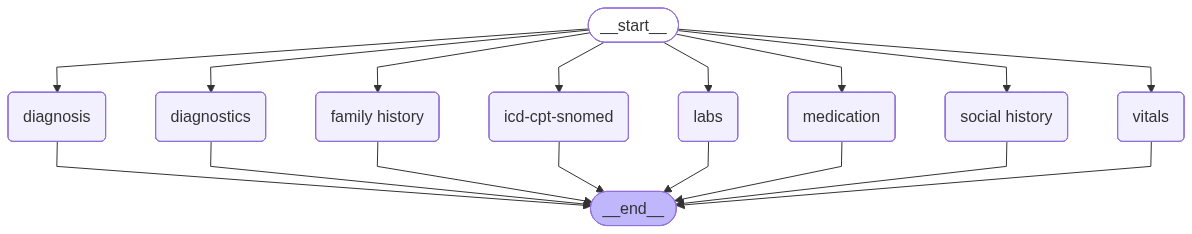

In [179]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [188]:
inputjson= r"shnotpresent.json"

with open(inputjson,'r') as f:
    inputtext=json.load(f)

all_text=inputtext["texts"]
page_num=1
page=page_num-1
test_page=all_text[page]
test_page

'01/23/2026 17:40 2157662790  PLUMSTEADVILLE  PAGE 05/65\nFASCIANO, PAUJLA DOB; Jul 17, 1968 (57 yc F} Acc Ma 632024\nAee Lennen nnlelnleeelnllenenene\nFASCIAND , PAULA DOB: 07/17/1968: (56 ya F) Acc: No. 632024 DosI_07/02/2025\nEASCIANO, PAULA\nS6Y &i Feurdte DOE: 07/*7/4968\nArvrtal Mualbre 632024\nDURENM " PZERSVILLE; Pa-48947\nRers: 848,700774829\nCuxarantor: EASIJANG FAULA Ineatance; Ggna\nRrerrise; Selv anagain luthuska\nAatsiatulrxet Nacil Aeteadvillo Fantly Fraetice\nI0 narttotouns t\nSrrttrntt=     #opoin  Giteor\n"07/02/2025\nRaasomno Apedicteient\nCarrena Medicetions\' Ii Lingering congh for-months\nIalnr; %00 MG Capswle is dirceted-Otally Assessments\nEstradiol 0  MG/CM Cream inaartf gar 1. Cqronic coueh Ro5 3 (Frimary)\nvorielly oncc daytor 14 d4yathen Mixed hyperlipidenaia E78.2\n\'TWCF WEEKEX"  Weigbt gain\' R6z 5;\nEetradiol 05 MG Tablet } tablet Oralt\nOnce aiay\'  Thranknete\nRoxuvastatin Calefun 5 MG Tablet $ tablet 1, \'Chronic cquigh\nOrally Once aday\nUri pS.83.SM

In [189]:
result = app.invoke({"text":test_page,"outtext":"sampleout"})
print(json.dumps(result, indent=4))

{
    "text": "01/23/2026 17:40 2157662790  PLUMSTEADVILLE  PAGE 05/65\nFASCIANO, PAUJLA DOB; Jul 17, 1968 (57 yc F} Acc Ma 632024\nAee Lennen nnlelnleeelnllenenene\nFASCIAND , PAULA DOB: 07/17/1968: (56 ya F) Acc: No. 632024 DosI_07/02/2025\nEASCIANO, PAULA\nS6Y &i Feurdte DOE: 07/*7/4968\nArvrtal Mualbre 632024\nDURENM \" PZERSVILLE; Pa-48947\nRers: 848,700774829\nCuxarantor: EASIJANG FAULA Ineatance; Ggna\nRrerrise; Selv anagain luthuska\nAatsiatulrxet Nacil Aeteadvillo Fantly Fraetice\nI0 narttotouns t\nSrrttrntt=     #opoin  Giteor\n\"07/02/2025\nRaasomno Apedicteient\nCarrena Medicetions' Ii Lingering congh for-months\nIalnr; %00 MG Capswle is dirceted-Otally Assessments\nEstradiol 0  MG/CM Cream inaartf gar 1. Cqronic coueh Ro5 3 (Frimary)\nvorielly oncc daytor 14 d4yathen Mixed hyperlipidenaia E78.2\n'TWCF WEEKEX\"  Weigbt gain' R6z 5;\nEetradiol 05 MG Tablet } tablet Oralt\nOnce aiay'  Thranknete\nRoxuvastatin Calefun 5 MG Tablet $ tablet 1, 'Chronic cquigh\nOrally Once aday\n